# K-means 聚类 

在本练习中，你将实现 K-means 算法并将其用于图像压缩。 

* 你将从一个样本数据集开始，帮助你理解 K-means 算法的工作原理。 
* 之后，你将使用 K-means 算法进行图像压缩，通过将图像中出现的颜色数量减少到该图像中最常见的那些颜色。




# 目录
- [ 1 - 实现 K-means](#1)
  - [ 1.1 寻找最近的质心](#1.1)
    - [ 练习 1](#ex01)
  - [ 1.2 计算质心均值](#1.2)
    - [ 练习 2](#ex02)
- [ 2 - 在样本数据集上运行 K-means ](#2)
- [ 3 - 随机初始化](#3)
- [ 4 - 使用 K-means 进行图像压缩](#4)
  - [ 4.1 数据集](#4.1)
  - [ 4.2 在图像像素上运行 K-Means](#4.2)
  - [ 4.3 压缩图像](#4.3)


_**注意：** 为防止自动评分器出错，你不允许编辑或删除本实验中的非评分单元格。请也不要添加任何新的单元格。 
**当你通过此作业后**，如果想尝试任何非评分代码，可以按照本笔记本底部的说明操作。_

首先，运行下面的单元格以导入本作业所需的包：

- [numpy](https://numpy.org/) 是 Python 科学计算的基础包。
- [matplotlib](http://matplotlib.org) 是 Python 中用于绘制图形的流行库。
- `utils.py` 包含本作业的辅助函数。你不需要修改此文件中的代码。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib inline

<a name="1"></a>
## 1 - 实现 K-means

K-means 算法是一种自动将相似数据点聚类在一起的方法。 

* 具体来说，给你一个训练集 $\{x^{(1)}, ..., x^{(m)}\}$，你想将数据分成几个有凝聚力的“簇”。 


* K-means 是一个迭代过程，它
     * 首先猜测初始质心，然后 
     * 通过以下方式改进这个猜测：
         * 反复将样本分配到它们最近的质心，然后 
         * 根据分配重新计算质心。
         

* 用伪代码表示，K-means 算法如下：

    ``` python
    # Initialize centroids
    # K is the number of clusters
    centroids = kMeans_init_centroids(X, K)
    
    for iter in range(iterations):
        # Cluster assignment step: 
        # Assign each data point to the closest centroid. 
        # idx[i] corresponds to the index of the centroid 
        # assigned to example i
        idx = find_closest_centroids(X, centroids)

        # Move centroid step: 
        # Compute means based on centroid assignments
        centroids = compute_centroids(X, idx, K)
    ```


* 算法的内循环反复执行两个步骤： 
    1. 将每个训练样本 $x^{(i)}$ 分配到其最近的质心，以及
    2. 使用分配给它的点重新计算每个质心的均值。 
    
    
* $K$-means 算法将始终收敛到质心的某组最终均值。 

* 然而，收敛的解可能并不总是理想的，这取决于质心的初始设置。
    * 因此，在实践中，K-means 算法通常会使用不同的随机初始化运行多次。 
    * 在这些不同随机初始化产生的不同解中进行选择的一种方法是选择具有最低代价函数值（失真）的那个。

你将在接下来的部分中分别实现 K-means 算法的两个阶段。 
* 你将首先完成 `find_closest_centroid`，然后继续完成 `compute_centroids`。

<a name="1.1"></a>
### 1.1 寻找最近的质心

在 K-means 算法的“簇分配”阶段，算法在给定质心当前位置的情况下，将每个训练样本 $x^{(i)}$ 分配到其最近的质心。 

<a name="ex01"></a>
### 练习 1

你的任务是完成 `find_closest_centroids` 中的代码。 
* 此函数接收数据矩阵 `X` 和所有质心的位置 `centroids` 
* 它应该输出一个一维数组 `idx`（与 `X` 具有相同数量的元素），其中包含每个训练样本最近质心的索引（$\{0,...,K-1\}$ 中的值，其中 $K$ 是质心总数）。*（注意：索引范围 0 到 K-1 与课程中显示的略有不同（即 1 到 K），因为 Python 列表索引从 0 开始而不是从 1 开始）*
* 具体来说，对于每个样本 $x^{(i)}$ 我们设置
$$c^{(i)} := j \quad \mathrm{that \; minimizes} \quad ||x^{(i)} - \mu_j||^2,$$
其中
 * $c^{(i)}$ 是距离 $x^{(i)}$ 最近的质心的索引（对应于起始代码中的 `idx[i]`），以及 
 * $\mu_j$ 是第 $j$ 个质心的位置（值）。（存储在起始代码中的 `centroids` 中）
 * $||x^{(i)} - \mu_j||$ 是 L2 范数
 
如果你遇到困难，可以查看下面单元格后面的提示来帮助你完成实现。

In [2]:
# UNQ_C1
# GRADED FUNCTION: find_closest_centroids

def find_closest_centroids(X, centroids):
    """
    计算每个样本的质心归属
    
    Args:
        X (ndarray): (m, n) 输入值      
        centroids (ndarray): (K, n) 质心
    
    Returns:
        idx (array_like): (m,) 最近的质心
    
    """

    # 设置 K
    K = centroids.shape[0]

    # 你需要正确返回以下变量
    idx = np.zeros(X.shape[0], dtype=int)

    ### START CODE HERE ###
    m = X.shape[0]
    for i in range(m):
        distances = []
        for j in range(centroids.shape[0]):
            norm_ij = np.linalg.norm(X[i] - centroids[j])
            distances.append(norm_ij)
        idx[i] = np.argmin(distances)
     ### END CODE HERE ###
    
    return idx

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
* 以下是你可以为此函数构建整体实现的方式

```python 
def find_closest_centroids(X, centroids):

    # Set K
    K = centroids.shape[0]

    # You need to return the following variables correctly
    idx = np.zeros(X.shape[0], dtype=int)

    ### START CODE HERE ###
    for i in range(X.shape[0]):
        # Array to hold distance between X[i] and each centroids[j]
        distance = [] 
        for j in range(centroids.shape[0]):
            norm_ij = # Your code to calculate the norm between (X[i] - centroids[j])
            distance.append(norm_ij)

        idx[i] = # Your code here to calculate index of minimum value in distance
    ### END CODE HERE ###
    return idx
```

* 如果你仍然卡住，可以查看下面的提示来计算 `norm_ij` 和 `idx[i]`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 norm_ij 的提示</b></font></summary>
           &emsp; &emsp; 你可以使用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html">np.linalg.norm</a> 来计算范数 
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 norm_ij 的更多提示</b></font></summary>
               &emsp; &emsp; 你可以这样计算 norm_ij：<code>norm_ij = np.linalg.norm(X[i] - centroids[j]) </code>
           </details>
    </details>

    <details>
          <summary><font size="2" color="darkblue"><b>计算 idx[i] 的提示</b></font></summary>
          &emsp; &emsp; 你可以使用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.argmin.html">np.argmin</a> 来找到最小值的索引
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 idx[i] 的更多提示</b></font></summary>
              &emsp; &emsp; 你可以这样计算 idx[i]：<code>idx[i] = np.argmin(distance)</code>
          </details>
    </details>
        
    </details>

</details>

    


现在让我们使用示例数据集检查你的实现

In [3]:
# 加载我们将要使用的示例数据集
X = load_data()

下面的代码打印变量 `X` 的前五个元素和变量的维度

In [4]:
print("First five elements of X are:\n", X[:5]) 
print('The shape of X is:', X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [5]:
# 选择一组初始质心（3 个质心）
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# 使用 initial_centroids 寻找最近的质心
idx = find_closest_centroids(X, initial_centroids)

# 打印前三个元素的最近质心
print("First three elements in idx are:", idx[:3])

# UNIT TEST
from public_tests import *

find_closest_centroids_test(find_closest_centroids)

First three elements in idx are: [0 2 1]
所有测试通过！


**预期输出**:
<table>
  <tr>
    <td> <b>First three elements in idx are<b></td>
    <td> [0 2 1] </td> 
  </tr>
</table>

<a name="1.2"></a>
### 1.2 计算质心均值

给定每个点到质心的分配，算法的第二阶段为每个质心重新计算分配给它的点的均值。


<a name="ex02"></a>
### 练习 2

请完成下面的 `compute_centroids` 以重新计算每个质心的值

* 具体来说，对于每个质心 $\mu_k$ 我们设置
$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$ 

    其中
    * $C_k$ 是分配给质心 $k$ 的样本集合
    * $|C_k|$ 是集合 $C_k$ 中的样本数量


* 具体来说，如果两个样本 $x^{(3)}$ 和 $x^{(5)}$ 被分配给质心 $k=2$，
那么你应该更新 $\mu_2 = \frac{1}{2}(x^{(3)}+x^{(5)})$。

如果你遇到困难，可以查看下面单元格后面的提示来帮助你完成实现。

In [6]:
# UNQ_C2
# GRADED FUNCTION: compute_centroids

def compute_centroids(X, idx, K):
    """
    通过计算分配给每个质心的数据点的均值来返回新的质心。
    
    Args:
        X (ndarray):   (m, n) 数据点
        idx (ndarray): (m,) 包含每个样本最近质心索引的数组
                       具体来说，idx[i] 包含距离样本 i 最近的质心的索引
        K (int):       质心数量
    
    Returns:
        centroids (ndarray): (K, n) 计算得到的新质心
    """
    
    # 有用的变量
    m, n = X.shape
    
    # 你需要正确返回以下变量
    centroids = np.zeros((K, n))
    
    ### START CODE HERE ###
    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points, axis = 0)
    ### END CODE HERE ## 
    
    return centroids

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
* 以下是你可以为此函数构建整体实现的方式
    ```python 
    def compute_centroids(X, idx, K):
        # Useful variables
        m, n = X.shape
    
        # You need to return the following variables correctly
        centroids = np.zeros((K, n))
    
        ### START CODE HERE ###
        for k in range(K):   
            points = # Your code here to get a list of all data points in X assigned to centroid k  
            centroids[k] = # Your code here to compute the mean of the points assigned
    ### END CODE HERE ## 
    
    return centroids
    ```
  
    如果你仍然卡住，可以查看下面的提示来计算 `points` 和 `centroids[k]`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 points 的提示</b></font></summary>
           &emsp; &emsp; 假设我们想找到 X 中所有分配给簇 <code>k=0</code> 的值，即这些样本在 idx 中对应的值为 0。在 Python 中，我们可以这样做：<code>X[idx == 0]</code>。类似地，分配给质心 <code>k=1</code> 的点是 <code>X[idx == 1]</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 points 的更多提示</b></font></summary>
               &emsp; &emsp; 你可以这样计算 points：<code>points = X[idx == k] </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>计算 centroids[k] 的提示</b></font></summary>
          &emsp; &emsp; 你可以使用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.mean.html">np.mean</a> 来求均值。请确保设置参数 <code>axis=0</code> 
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 centroids[k] 的更多提示</b></font></summary>
              &emsp; &emsp; 你可以这样计算 centroids[k]：<code>centroids[k] = np.mean(points, axis = 0)</code>
          </details>
    </details>
        
    </details>

</details>

    


现在通过运行下面的单元格来检查你的实现

In [7]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)

# UNIT TEST
compute_centroids_test(compute_centroids)

The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]
所有测试通过！


**预期输出**:

2.42830111 3.15792418

5.81350331 2.63365645

7.11938687 3.6166844 

<a name="2"></a>
## 2 - 在样本数据集上运行 K-means 

在你完成上面的两个函数（`find_closest_centroids` 和 `compute_centroids`）之后，下一步是在一个简单的二维数据集上运行 K-means 算法，以帮助你理解 K-means 的工作原理。 
* 我们建议你查看下面的函数（`run_kMeans`）以了解它是如何工作的。 
* 请注意，代码在循环中调用了你实现的两个函数。

当你运行下面的代码时，它将生成一个可视化，逐步展示算法在每次迭代中的进展。 
* 最后，你的图形应该看起来像图 1 中显示的那样。
* 最终的质心是彩色簇中间的黑色 X 标记。
* 你可以通过查看与之相连的其他 X 标记来了解这些质心是如何到达最终位置的。

<img src="images/figure 1.png" width="500" height="500">


**注意**：此部分你不需要实现任何内容。只需运行下面提供的代码即可

In [8]:
# 此部分你不需要实现任何内容

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    在数据矩阵 X 上运行 K-Means 算法，其中 X 的每一行是一个样本
    """
    
    # 初始化值
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))

    # 运行 K-Means
    for i in range(max_iters):
        
        #输出进度
        print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        # 对于 X 中的每个样本，将其分配给最近的质心
        idx = find_closest_centroids(X, centroids)
        
        # 可选地绘制进度
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids
            
        # 根据成员关系计算新的质心
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAPH-8FED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


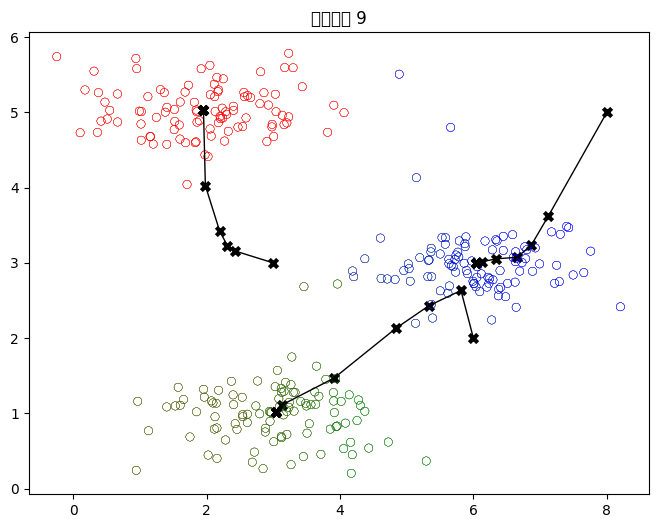

In [9]:
# 加载示例数据集
X = load_data()

# 设置初始质心
initial_centroids = np.array([[3,3],[6,2],[8,5]])

# 迭代次数
max_iters = 10

# 运行 K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

<a name="3"></a>
## 3 - 随机初始化

示例数据集的质心初始分配是经过设计的，以便你看到与图 1 相同的图形。在实践中，初始化质心的一个好策略是从训练集中随机选择样本。

在本练习的这部分，你应该理解 `kMeans_init_centroids` 函数是如何实现的。
* 代码首先随机打乱样本的索引（使用 `np.random.permutation()`）。 
* 然后，它基于索引的随机排列选择前 $K$ 个样本。 
* 这使得样本可以被随机选择，而不会有重复选择同一样本的风险。

**注意**：此部分练习你不需要实现任何内容。

In [10]:
# 此部分你不需要修改

def kMeans_init_centroids(X, K):
    """
    此函数初始化要在 K-Means 中使用的 K 个质心
    
    Args:
        X (ndarray): 数据点 
        K (int):     质心/簇的数量
    
    Returns:
        centroids (ndarray): 初始化的质心
    """
    
    # 随机重新排列样本的索引
    randidx = np.random.permutation(X.shape[0])
    
    # 取前 K 个样本作为质心
    centroids = X[randidx[:K]]
    
    return centroids

你可以再次运行 K-Means，但这次使用随机初始质心。多次运行下面的单元格，观察基于所选初始点如何创建不同的簇。

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


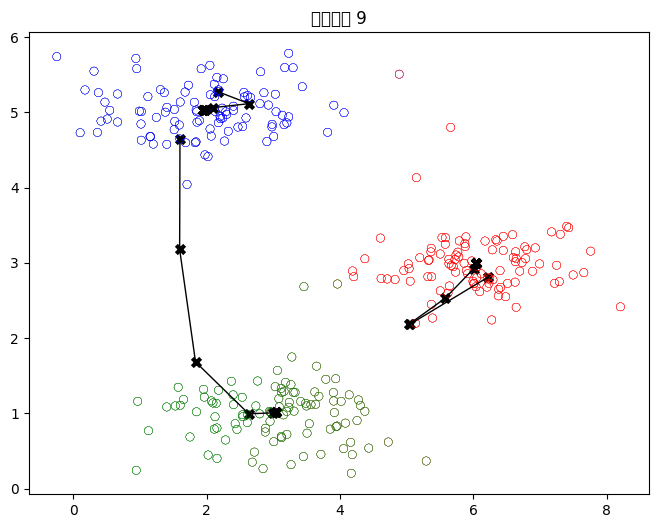

In [11]:
# 重复运行此单元格以查看不同的结果。

# 设置质心数量和最大迭代次数
K = 3
max_iters = 10

# 通过从数据集中随机选择样本来设置初始质心
initial_centroids = kMeans_init_centroids(X, K)

# 运行 K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

<a name="4"></a>
## 4 - 使用 K-means 进行图像压缩

在本练习中，你将把 K-means 应用于图像压缩。 

* 在简单的 24 位颜色图像表示$^{2}$中，每个像素由三个 8 位无符号整数（范围从 0 到 255）表示，分别指定红色、绿色和蓝色强度值。这种编码通常被称为 RGB 编码。
* 我们的图像包含数千种颜色，在本练习的这部分，你将把颜色数量减少到 16 种。
* 通过这种减少，可以有效地表示（压缩）照片。 
* 具体来说，你只需要存储 16 种选定颜色的 RGB 值，对于图像中的每个像素，你现在只需要存储该位置颜色的索引（其中只需要 4 位就可以表示 16 种可能性）。

在本部分，你将使用 K-means 算法来选择用于表示压缩图像的 16 种颜色。
* 具体来说，你将把原始图像中的每个像素视为一个数据样本，并使用 K-means 算法在三维 RGB 空间中找到最能将像素分组（聚类）的 16 种颜色。
* 一旦你在图像上计算了簇质心，你将使用这 16 种颜色替换原始图像中的像素。

<img src="images/figure 2.png" width="500" height="500">

$^{2}$<sub>本练习中使用的照片属于 Frank Wouters，并经其许可使用。</sub>

<a name="4.1"></a>
### 4.1 数据集

**加载图像**

首先，你将使用 `matplotlib` 读取原始图像，如下所示。

In [12]:
# 加载一张鸟的图片
original_img = plt.imread('bird_small.png')

**可视化图像**

你可以使用下面的代码可视化刚刚加载的图像。

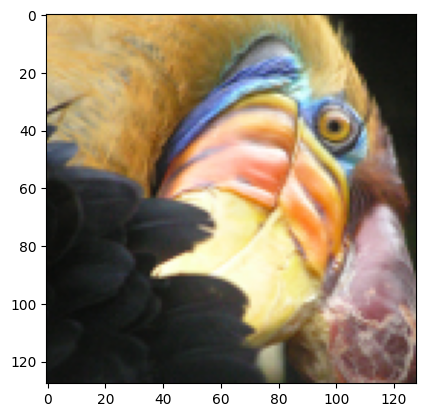

In [13]:
# 可视化图像
plt.imshow(original_img)

**检查变量的维度**

和往常一样，你将打印出变量的形状以更好地了解数据。

In [14]:
print("Shape of original_img is:", original_img.shape)

Shape of original_img is: (128, 128, 3)


如你所见，这创建了一个三维矩阵 `original_img`，其中
* 前两个索引标识像素位置，以及
* 第三个索引表示红色、绿色或蓝色。 

例如，`original_img[50, 33, 2]` 给出第 50 行第 33 列像素的蓝色强度。

#### 处理数据

要调用 `run_kMeans`，你需要首先将矩阵 `original_img` 转换为二维矩阵。

* 下面的代码重塑矩阵 `original_img` 以创建一个 $m \times 3$ 的像素颜色矩阵（其中
$m=16384 = 128\times128$）

*注意：如果你稍后尝试在 JPG 文件上进行此练习，你需要首先将像素值除以 255，使其在 0 到 1 的范围内。对于 PNG 文件（例如 `bird_small.png`）则不需要这样做，因为它已经以所需的范围加载（如 [plt.imread() 文档](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imread.html)中所述）。我们在下面注释了一行代码，以便你稍后可以取消注释，如果你想尝试不同的文件。* 

In [15]:
# 除以 255 使所有值在 0 - 1 的范围内（PNG 文件不需要）
# original_img = original_img / 255

# 将图像重塑为 m x 3 的矩阵，其中 m = 像素数量
# （在本例中 m = 128 x 128 = 16384）
# 每行将包含红色、绿色和蓝色像素值
# 这给了我们将使用 K-Means 的数据集矩阵 X_img。

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

<a name="4.2"></a>
### 4.2 在图像像素上运行 K-Means

现在，运行下面的单元格以在预处理后的图像上运行 K-Means。

In [16]:
# 在此数据上运行你的 K-Means 算法
# 你应该在这里尝试不同的 K 和 max_iters 值
K = 16
max_iters = 10

# 使用你在上面实现的函数。
initial_centroids = kMeans_init_centroids(X_img, K)

# 运行 K-Means - 根据 K 和 max_iters 的不同，这可能需要几分钟
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


<Figure size 800x600 with 0 Axes>

In [17]:
print("Shape of idx:", idx.shape)
print("Closest centroid for the first five elements:", idx[:5])

Shape of idx: (16384,)
Closest centroid for the first five elements: [ 0 12 12 12  0]


下面的代码将绘制原始图像中找到的所有颜色。如前所述，每个像素的颜色由 RGB 值表示，因此该图应有 3 个轴 -- R、G 和 B。你会注意到下面有很多点，代表原始图像中的数千种颜色。红色标记代表运行 K-means 后的质心。这些将是你用来压缩图像的 16 种颜色。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32511 (\N{CJK UNIFIED IDEOGRAPH-7EFF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34013 (\N{CJK UNIFIED IDEOGRAPH-84DD}) m

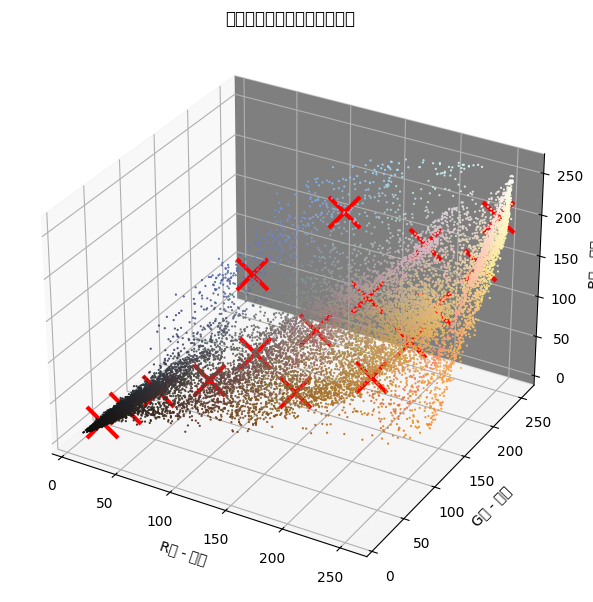

In [18]:
# 绘制图像的颜色并标记质心
plot_kMeans_RGB(X_img, centroids, idx, K)

你可以使用下面的函数可视化上面每个红色标记处的颜色（即质心）。只有在下一部分生成新图像时，你才会看到这些颜色。每种颜色下方的数字是其索引，这些是你在 `idx` 数组中看到的数字。

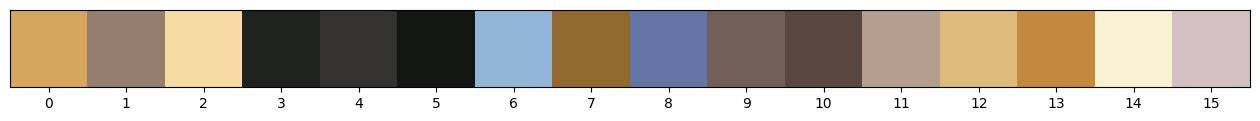

In [19]:
# 可视化选定的 16 种颜色
show_centroid_colors(centroids)

<a name="4.3"></a>
### 4.3 压缩图像


在找到用于表示图像的前 $K=16$ 种颜色后，你现在可以使用 `find_closest_centroids` 函数将每个像素位置分配到其最近的质心。 
* 这使你可以使用每个像素的质心分配来表示原始图像。 
* 请注意，你已经显著减少了描述图像所需的位数。 
    * 原始图像需要 24 位（即 RGB 编码中的 8 位 x 3 个通道）来表示 $128\times128$ 个像素位置中的每一个，总大小为 $128 \times 128 \times 24 = 393,216$ 位。 
    * 新的表示形式需要一些额外的存储空间来保存一个包含 16 种颜色的字典，每种颜色需要 24 位，但图像本身每个像素位置只需要 4 位。 
    * 因此，使用的最终位数为 $16 \times 24 + 128 \times 128 \times 4 = 65,920$ 位，这相当于将原始图像压缩了约 6 倍。

In [20]:
# 找到每个像素的最近质心
idx = find_closest_centroids(X_img, centroids)

# 用最近质心的颜色替换每个像素
X_recovered = centroids[idx, :] 

# 将图像重塑为适当的维度
X_recovered = np.reshape(X_recovered, original_img.shape) 

最后，你可以通过仅基于质心分配重建图像来查看压缩的效果。 
* 具体来说，你用分配给它的质心的值替换了每个像素。 
* 图 3 显示了一个示例重建。尽管生成的图像保留了原始图像的大部分特征，但由于使用的颜色较少，你也会看到一些压缩伪影。

<img src="images/figure 3.png" width="700" height="700">

* 运行下面的代码，查看如何使用前面选择的 16 种颜色重建图像。

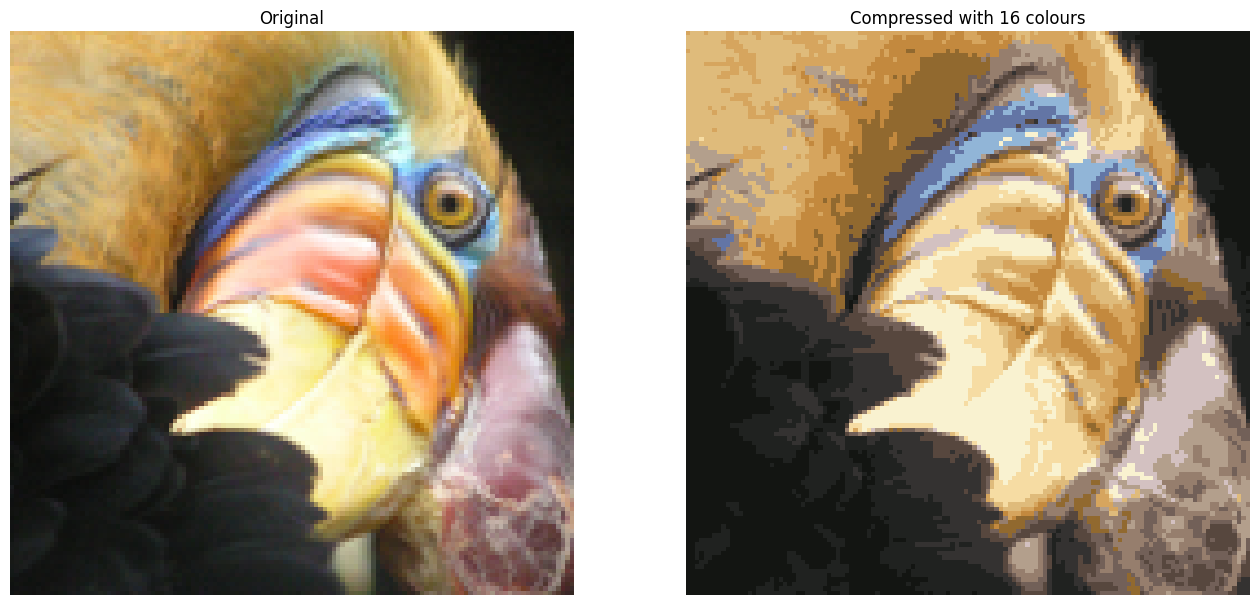

In [21]:
# 显示原始图像
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()


# 显示压缩后的图像
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()

**恭喜你完成了关于 K-means 聚类的实验！在下一课中，你将学习无监督学习的另一个用例：异常检测。到时见！**

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想尝试任何非评分代码，请点击此处。</b></font></summary>
    <p><i><b>重要提示：请仅在你已经通过作业后才这样做，以避免自动评分器出现问题。</b></i>
    <ol>
        <li> 在笔记本的菜单中，点击“视图” > “单元格工具栏” > “编辑元数据”</li>
        <li> 点击你想锁定/解锁的代码单元格旁边的“编辑元数据”按钮</li>
        <li> 将“editable”的属性值设置为：
            <ul>
                <li> “true” 如果你想解锁它 </li>
                <li> “false” 如果你想锁定它 </li>
            </ul>
        </li>
        <li> 在笔记本的菜单中，点击“视图” > “单元格工具栏” > “无” </li>
    </ol>
    <p> 以下是上述步骤的简短演示： 
        <br>
        <img src="https://drive.google.com/uc?export=view&id=14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>